# Time-Dependent Equilibrium with TokaMaker

Vessel eddy currents, wall eigenmodes, quasi-static shot evolution, and
vertical-stability growth rates with **TokaMaker** (Open FUSION Toolkit,
arXiv:2311.07719) through `vaft.code.tokamaker`. This builds on the static
forward notebook (`forward_equilibrium_using_TokaMaker`) by activating
`TokaMakerConfig.include_vessel`: the VEST vacuum vessel is meshed as resistive
conductor regions synthesized from the `pf_passive` filament segments.

    ods ── tokamaker_geometry_from_ods ────▶ geometry (+ vessel conductors)
        ── build_tokamaker_mesh ───────────▶ vest_gs_mesh_<hash>.h5 (cached)
        ── run_tokamaker_wall_eigenmodes ──▶ wall L/R time constants (eig_wall)
        ── run_tokamaker_evolution ────────▶ per-slice g-files + eddy currents
        ── run_tokamaker_vertical_stability▶ n=0 growth rate gamma (eig_td)

Conductors are inert in *static* solves (every eddy term in TokaMaker is gated
on `dt > 0`), so one mesh serves both this notebook and the static workflow.
The nonlinear vertical-displacement evolution (`setup_td`/`step_td`) is
deliberately out of scope here. Solver cells are skipped when
OpenFUSIONToolkit is not importable (see `initialize_external_fusion_codes.ipynb`).

In [ ]:
import time as _time
from dataclasses import replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from omas import ODS

import vaft
from vaft.code import tokamaker

WORKDIR = Path("_tokamaker_run") / "time_dependent"
WORKDIR.mkdir(parents=True, exist_ok=True)

try:
    tokamaker._oft.import_oft()
    OFT_AVAILABLE = True
except ImportError as exc:
    OFT_AVAILABLE = False
    print(exc)
print("OpenFUSIONToolkit available:", OFT_AVAILABLE)

OpenFUSIONToolkit available: True


## 1. Load a shot and normalize the machine geometry

The canonical VEST limiter and the packaged 950-loop `pf_passive` filament set
are applied after loading — database `wall`/`pf_passive` entries vary by
processing era, and both the vessel synthesis and the free-boundary solve need
the full canonical geometry.

In [ ]:
SHOT, TIME = 39915, 0.325

def load_shot():
    try:
        loaded = vaft.database.load(SHOT)
        print(f"loaded shot {SHOT} via vaft.database.load")
        return loaded
    except Exception as e:
        sample = Path(vaft.__file__).parent / "data" / "omas" / f"{SHOT}.json"
        print(f"vaft.database.load unavailable ({type(e).__name__}); using bundled {sample.name}")
        return vaft.omas.load_omas_json(sample, consistency_check=False)

ods = load_shot()

from vaft.machine_mapping.wall import wall as canonical_wall
from vaft.machine_mapping.pf_passive import pf_passive as canonical_pf_passive
canonical_wall(ods)
canonical_pf_passive(ods)

print(f"  pf_passive   = {len(ods['pf_passive.loop'])} filament loops")
print(f"  pf_active    = {len(ods['pf_active.coil'])} coils")
print(f"  equilibrium  = {len(ods['equilibrium.time'])} EFIT slices "
      f"({ods['equilibrium.time'][0]:.3f}-{ods['equilibrium.time'][-1]:.3f} s)")

22:13:02 INFO     Parsing data dictionary version 3.41.0 @dd_zip.py:89


INFO:imas.dd_zip:Parsing data dictionary version 3.41.0


Successfully loaded ODS data for shot: 39915
loaded shot 39915 via vaft.database.load


  pf_passive   = 950 filament loops
  pf_active    = 10 coils
  equilibrium  = 8 EFIT slices (0.316-0.327 s)


## 2. Vessel conductor regions from `pf_passive`

Filament loops are grouped by segment name (`W1`..`W10`), mirrored halves are
split into `_U`/`_L` regions, abutting/overlapping corner joints are made
exactly disjoint, and each region gets a resistivity: **7.8e-7 Ohm·m**
(SUS316LN) reproduces the packaged W2–W10 loop resistances exactly. The
outboard wall `W1` carries a black-box per-loop calibration in the ODS
(issue #191) — its median is shown for provenance but the uniform default is
applied. `W11` (0.1 mm tungsten limiter tiles) is excluded: tiles, not
structure, and unmeshable.

region  loops           R [m]             Z [m]      dx       eta  eta(ODS)
W1        234 [0.800, 0.806] [-0.585, +0.585]   4.7mm 7.8e-07 5.9e-07
W10_L       8 [0.520, 0.673] [-1.200, -1.185]  13.7mm 7.8e-07 7.8e-07
W10_U       8 [0.520, 0.673] [+1.185, +1.200]  13.7mm 7.8e-07 7.8e-07
W2_L        8 [0.134, 0.280] [-1.202, -1.185]  16.7mm 7.8e-07 7.8e-07
W2_U        8 [0.134, 0.280] [+1.185, +1.202]  16.7mm 7.8e-07 7.8e-07
W3_L       23 [0.130, 0.134] [-1.199, -0.745]   4.0mm 7.8e-07 7.8e-07
W3_U       23 [0.130, 0.134] [+0.745, +1.199]   4.0mm 7.8e-07 7.8e-07
W4        230 [0.080, 0.082] [-0.574, +0.574]   4.0mm 7.8e-07 7.8e-07
W5_L       10 [0.083, 0.132] [-0.745, -0.574]   4.7mm 7.8e-07 7.8e-07
W5_U       10 [0.083, 0.132] [+0.574, +0.745]   4.7mm 7.8e-07 7.8e-07
W6_L       29 [0.600, 0.606] [-1.185, -0.615]   5.7mm 7.8e-07 7.8e-07
W6_U       29 [0.600, 0.606] [+0.615, +1.185]   5.7mm 7.8e-07 7.8e-07
W7_L       22 [0.250, 0.673] [-1.215, -1.200]  14.7mm 7.8e-07 7.8e-07
W7_U       22 

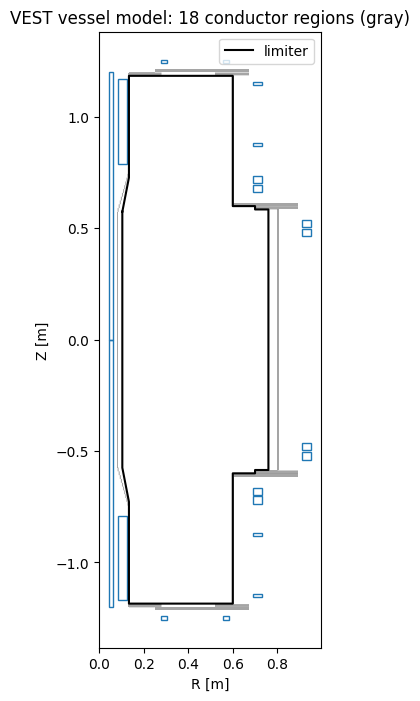

In [ ]:
cfg = tokamaker.TokaMakerConfig(shot=SHOT, time=TIME, workdir=WORKDIR, include_vessel=True)
vessel = tokamaker.vessel_segments_from_ods(ods, cfg)

print(f"{'region':7s} {'loops':>5s} {'R [m]':>15s} {'Z [m]':>17s} {'dx':>7s} {'eta':>9s} {'eta(ODS)':>9s}")
for name, reg in sorted(vessel.items()):
    c = np.asarray(reg["contour"])
    print(f"{name:7s} {reg['n_loops']:5d} "
          f"[{c[:,0].min():.3f}, {c[:,0].max():.3f}] "
          f"[{c[:,1].min():+.3f}, {c[:,1].max():+.3f}] "
          f"{reg['dx']*1e3:5.1f}mm {reg['eta']:.1e} {reg['eta_ods_median']:.1e}")

geometry = tokamaker.tokamaker_geometry_from_ods(ods, cfg)
fig, ax = plt.subplots(figsize=(5.5, 8))
lim = np.asarray(geometry["limiter"])
ax.plot(np.r_[lim[:, 0], lim[0, 0]], np.r_[lim[:, 1], lim[0, 1]], "k-", lw=1.5, label="limiter")
for name, coil in geometry["coils"].items():
    ax.add_patch(plt.Rectangle((coil["rc"] - coil["w"]/2, coil["zc"] - coil["h"]/2),
                               coil["w"], coil["h"], fill=False, edgecolor="tab:blue"))
for name, reg in vessel.items():
    c = np.asarray(reg["contour"])
    ax.fill(np.r_[c[:, 0], c[0, 0]], np.r_[c[:, 1], c[0, 1]],
            color="tab:gray", alpha=0.7, lw=0)
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.set_aspect("equal")
ax.set_title(f"VEST vessel model: {len(vessel)} conductor regions (gray)")
ax.legend(loc="upper right")
plt.show()

## 3. Mesh and wall eigenmodes

`eig_wall` needs only the mesh and finite-element setup — no equilibrium.
Eigenvalues are `1/tau` [1/s], so the leading mode gives the longest wall L/R
time constant. Mode patterns are saved to an `.npz` (with the mesh arrays) so
they can be re-plotted without a live solver handle.

mesh: vest_gs_mesh_cfd5052494.h5 (cached)
mesh ready in 0.0 s
#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           6d56801
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/oft_80035/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   44002
    # of edges   =  131839
    # of cells   =   87838
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  5.676E-05
    hrms =  1.016E-02
    hmax =


 Computing flux BC matrix 


ok: True
  mode 0: tau =  6.881 ms
  mode 1: tau =  5.680 ms
  mode 2: tau =  3.976 ms
  mode 3: tau =  3.845 ms
  mode 4: tau =  1.751 ms
  mode 5: tau =  1.751 ms
  mode 6: tau =  1.541 ms
  mode 7: tau =  1.238 ms


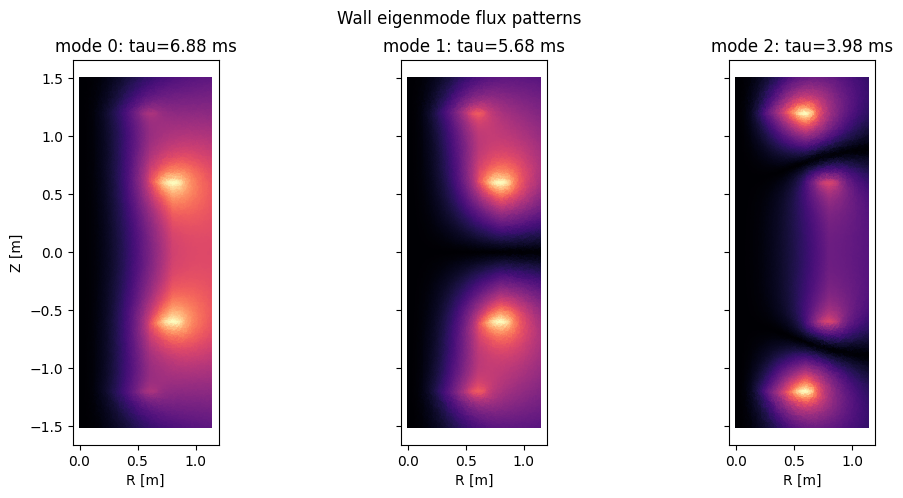

In [ ]:
inputs = tokamaker.prepare_tokamaker_inputs(ods, cfg)
print("mesh:", inputs.mesh_file.name, "(cached)" if inputs.mesh_exists else "(to build)")

if OFT_AVAILABLE:
    t0 = _time.time()
    tokamaker.build_tokamaker_mesh(inputs.geometry, inputs.mesh_file, cfg)
    print(f"mesh ready in {_time.time()-t0:.1f} s")

    wall_modes = tokamaker.run_tokamaker_wall_eigenmodes(inputs, cfg)
    print("ok:", wall_modes.ok)
    for i, tau in enumerate(wall_modes.tau_wall_s):
        print(f"  mode {i}: tau = {tau*1e3:6.3f} ms")

    saved = np.load(wall_modes.eig_file)
    r, lc = saved["mesh_r"], saved["mesh_lc"]
    fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
    for i, ax in enumerate(axes):
        vec = saved["eig_vecs"][i]
        ax.tripcolor(r[:, 0], r[:, 1], lc, np.abs(vec), cmap="magma")
        ax.set_title(f"mode {i}: tau={wall_modes.tau_wall_s[i]*1e3:.2f} ms")
        ax.set_xlabel("R [m]"); ax.set_aspect("equal")
    axes[0].set_ylabel("Z [m]")
    fig.suptitle("Wall eigenmode flux patterns")
    plt.show()
else:
    print("OpenFUSIONToolkit not available - skipping")

## 4. Static regression on the vessel mesh

Conductor regions carry no current in a static solve, so this must reproduce
the static notebook's equilibrium (same targets, finer mesh) — a built-in
consistency check of the vessel model.

In [ ]:
if OFT_AVAILABLE:
    static = tokamaker.run_tokamaker(inputs, cfg)
    print("ok:", static.ok)
    if static.ok:
        for key in ("Ip", "R_geo", "a_geo", "kappa", "q_0", "q_95", "beta_pol", "l_i"):
            print(f"  {key:9s} = {static.scalars[key]:.4g}")
else:
    print("OpenFUSIONToolkit not available - skipping")


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage


  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   44002
    # of edges   =  131839
    # of cells   =   87838
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  5.676E-05
    hrms =  1.016E-02
    hmax =  7.294E-02
  Surface grounded at vertex    3700


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



 Computing flux BC matrix 


Saving gEQDSK: _tokamaker_run/time_dependent/g039915.00325


 Using COCOS=2...
ok: True
  Ip        = 5.019e+04
  R_geo     = 0.3389
  a_geo     = 0.1722
  kappa     = 1.178
  q_0       = 0.7143
  q_95      = 2.331
  beta_pol  = 5.47
  l_i       = 1.19


## 5. Quasi-static shot evolution with wall eddy currents

The shot is re-run as a chain of solves: measured PF currents and the measured
Ip target at each slice, with the previous flux state feeding the
backward-Euler wall term (`set_psi_dt`). Converged slices are exported as
g-files and merged into a multi-slice `equilibrium` IDS; the net toroidal
current of every vessel region is recorded per slice.


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   44002
    # of edges   =  131839
    # of cells   =   87838
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  5.676E-05
    hrms =  1.016E-02
    hmax =  7.294E-02
  Surface grounded at vertex    3700


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



 Computing flux BC matrix 


Saving gEQDSK: _tokamaker_run/time_dependent/evolve/g039915.00314
 Using COCOS=2...


Saving gEQDSK: _tokamaker_run/time_dependent/evolve/g039915.00316
 Using COCOS=2...


Saving gEQDSK: _tokamaker_run/time_dependent/evolve/g039915.00318
 Using COCOS=2...


...

Saving gEQDSK: _tokamaker_run/time_dependent/evolve/g039915.00324


 Using COCOS=2...


Saving gEQDSK: _tokamaker_run/time_dependent/evolve/g039915.00326
 Using COCOS=2...


Saving gEQDSK: _tokamaker_run/time_dependent/evolve/g039915.00328
 Using COCOS=2...


slices: 8  failed: 0


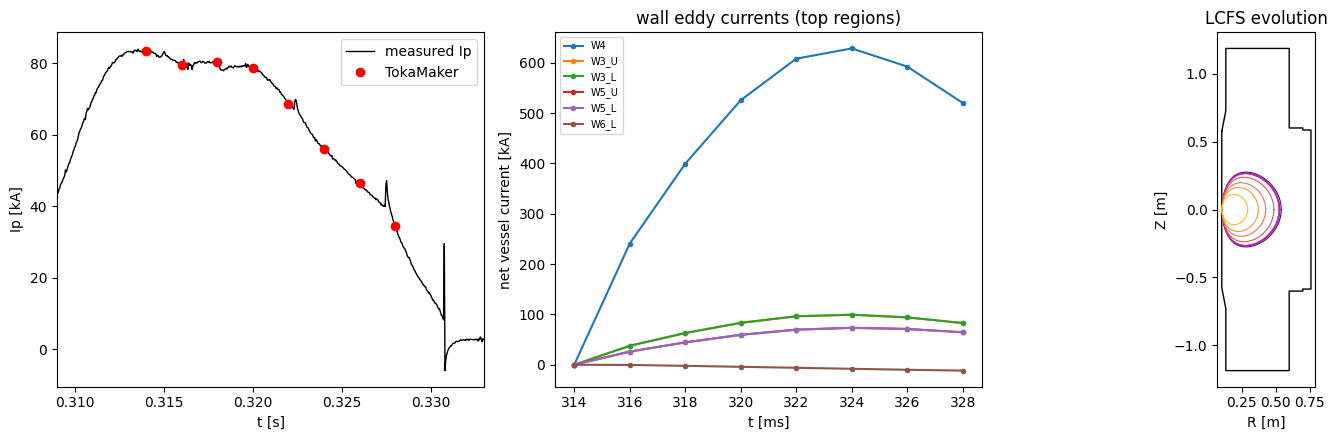

In [ ]:
if OFT_AVAILABLE:
    ecfg = replace(cfg, workdir=WORKDIR / "evolve", mesh_file=inputs.mesh_file,
                   constraint_source="magnetics",
                   evolve_start=0.314, evolve_end=0.329, evolve_dt=0.002)
    einp = tokamaker.prepare_tokamaker_evolution_inputs(ods, ecfg)
    evo = tokamaker.run_tokamaker_evolution(einp, ecfg)
    print(f"slices: {len(evo.steps)}  failed: {evo.scalars['n_failed']}")

    times = np.array([rec.time for rec in evo.steps])
    ip_run = np.array([rec.stats.get("Ip", np.nan) for rec in evo.steps])
    mg = ods["magnetics"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].plot(mg["ip.0.time"], np.asarray(mg["ip.0.data"]) / 1e3, "k-", lw=1, label="measured Ip")
    axes[0].plot(times, ip_run / 1e3, "ro", label="TokaMaker")
    axes[0].set_xlim(times[0] - 0.005, times[-1] + 0.005)
    axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("Ip [kA]"); axes[0].legend()

    regions = sorted(evo.steps[0].vessel_currents_A,
                     key=lambda k: -max(abs(rec.vessel_currents_A.get(k, 0.0)) for rec in evo.steps))
    for name in regions[:6]:
        trace = [rec.vessel_currents_A.get(name, np.nan) for rec in evo.steps]
        axes[1].plot(times * 1e3, np.asarray(trace) / 1e3, marker=".", label=name)
    axes[1].set_xlabel("t [ms]"); axes[1].set_ylabel("net vessel current [kA]")
    axes[1].legend(fontsize=7); axes[1].set_title("wall eddy currents (top regions)")

    lim = np.asarray(inputs.geometry["limiter"])
    axes[2].plot(np.r_[lim[:, 0], lim[0, 0]], np.r_[lim[:, 1], lim[0, 1]], "k-", lw=1)
    if evo.ods is not None:
        nsl = len(evo.ods["equilibrium.time"])
        colors = plt.cm.plasma(np.linspace(0.15, 0.85, nsl))
        for i in range(nsl):
            b = evo.ods[f"equilibrium.time_slice.{i}.boundary.outline"]
            axes[2].plot(b["r"], b["z"], color=colors[i], lw=0.8)
    axes[2].set_xlabel("R [m]"); axes[2].set_ylabel("Z [m]"); axes[2].set_aspect("equal")
    axes[2].set_title("LCFS evolution")
    fig.tight_layout()
    plt.show()
else:
    print("OpenFUSIONToolkit not available - skipping")

## 6. Vertical-stability growth rate

`eig_td` on the converged equilibrium gives the n=0 spectrum; the growth rate
is `gamma = -eig_vals[0,0]` [1/s] (positive = unstable, e-folding time
`1/gamma`). For strongly unstable cases a Vertical Stability Coil pair can
hold the *static* solve: `vsc_coil="PF9"` splits PF9 into upper/lower coil
sets driven differentially by the virtual `#VSC` (note: this changes the coil
sets, hence a different cached mesh).

In [ ]:
if OFT_AVAILABLE:
    vert = tokamaker.run_tokamaker_vertical_stability(inputs, cfg)
    print("ok:", vert.ok)
    if vert.ok:
        print(f"  gamma = {vert.gamma_s:.1f} 1/s  ->  e-folding {1e3/abs(vert.gamma_s):.2f} ms; "
              f"stable: {vert.scalars['stable']}")
        print(f"  (wall tau_max = {wall_modes.tau_wall_s[0]*1e3:.2f} ms for comparison)")
    else:
        print("  error:", vert.error)
else:
    print("OpenFUSIONToolkit not available - skipping")


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   44002
    # of edges   =  131839
    # of cells   =   87838
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  5.676E-05
    hrms =  1.016E-02
    hmax =  7.294E-02
  Surface grounded at vertex    3700


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



 Computing flux BC matrix 


Saving gEQDSK: _tokamaker_run/time_dependent/g039915.00325
 Using COCOS=2...


ok: True
  gamma = -144.2 1/s  ->  e-folding 6.93 ms; stable: True
  (wall tau_max = 6.88 ms for comparison)


## 7. Vacuum-window benchmark (issue #190 pattern)

Over the pre-plasma window the wall is driven by the PF coil waveforms alone,
so measured magnetics test the vessel model directly and independently of any
plasma physics. Two TokaMaker vacuum runs — coil-only (`evolve_eddy=False`)
and coil+eddy — are evaluated at the standard validation channels and compared
against the measurements *and* the existing 950-loop circuit model
(`vaft.omas.vacuum_magnetics`). Note the caveat from issue #216: the circuit
model's routine product is driven by the FL10-corrected Ip, but on this
plasma-free window both models see PF currents only, so the comparison is clean.

plasma onset 0.301 s; validating 10 channels



**** Loading OFT surface mesh



**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   44002
    # of edges   =  131839
    # of cells   =   87838
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  5.676E-05
    hrms =  1.016E-02
    hmax =  7.294E-02
  Surface grounded at vertex    3700


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



 Computing flux BC matrix 


  coil: ok=True



**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   44002
    # of edges   =  131839
    # of cells   =   87838
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  5.676E-05
    hrms =  1.016E-02
    hmax =  7.294E-02
  Surface grounded at vertex    3700


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



 Computing flux BC matrix 


  coil_eddy: ok=True


Successfully loaded ODS data for shot: 39915
loaded shot 39915 via vaft.database.load


metric                          TokaMaker circuit model
median eddy improvement            0.3095        0.3345
plasma_current_onset               0.3008        0.3008
plasma_onset                       0.3008        0.3008
schema_version                          1             1


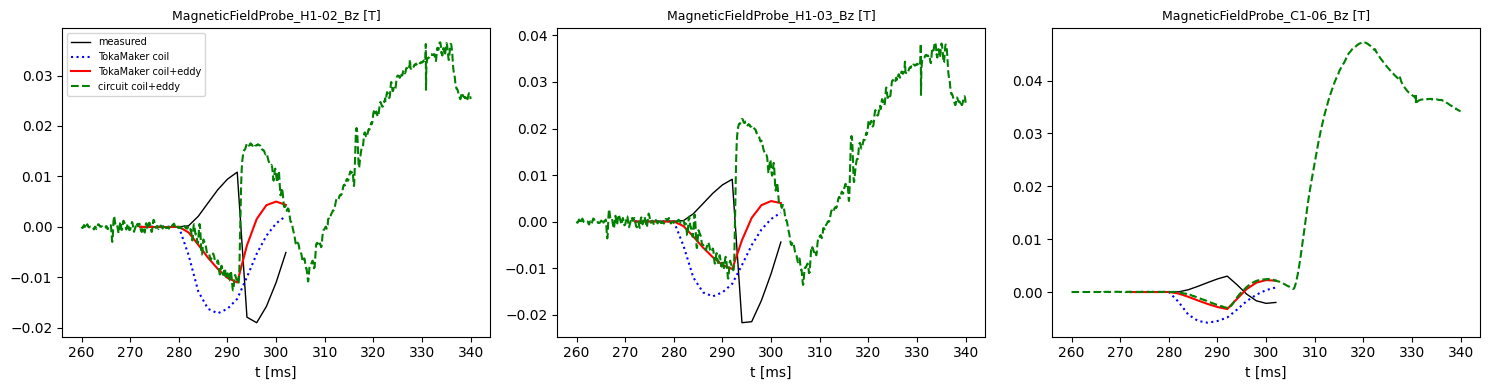

In [ ]:
if OFT_AVAILABLE:
    from vaft.omas.vacuum_magnetics import (
        VacuumChannel, plasma_onset_time, select_vacuum_channels,
        synthetic_vacuum_magnetics, vacuum_magnetics_metrics,
    )

    onset = plasma_onset_time(ods)
    rows = select_vacuum_channels(ods)
    print(f"plasma onset {onset:.3f} s; validating {len(rows)} channels")
    probes = tuple((row["r"], row["z"]) for row in rows)

    runs = {}
    for tag, eddy in (("coil", False), ("coil_eddy", True)):
        vcfg = replace(cfg, workdir=WORKDIR / f"vacuum_{tag}", mesh_file=inputs.mesh_file,
                       evolve_vacuum=True, evolve_eddy=eddy,
                       evolve_start=0.272, evolve_end=0.303, evolve_dt=0.002,
                       evolve_field_probes=probes)
        runs[tag] = tokamaker.run_tokamaker_evolution(
            tokamaker.prepare_tokamaker_evolution_inputs(ods, vcfg), vcfg)
        print(f"  {tag}: ok={runs[tag].ok}")

    vtimes = np.array([rec.time for rec in runs["coil_eddy"].steps])

    def synthetic(run, row, k):
        br = np.array([rec.probe_fields["br"][k] for rec in run.steps])
        bz = np.array([rec.probe_fields["bz"][k] for rec in run.steps])
        psi = np.array([rec.probe_fields["psi"][k] for rec in run.steps])
        if row["kind"] == "b_field_pol_probe":
            theta = row.get("poloidal_angle") or 0.0
            return br * np.cos(theta) + bz * np.sin(theta)
        return 2.0 * np.pi * psi          # flux loop: Wb/rad -> Wb

    tok_channels = tuple(
        VacuumChannel(
            name=row["name"], kind=row["kind"], family=row["family"], index=row["index"],
            r=row["r"], z=row["z"], unit=row["unit"], time=vtimes,
            measured=np.interp(vtimes, row["time"], row["data"]),
            coil=synthetic(runs["coil"], row, k),
            coil_eddy=synthetic(runs["coil_eddy"], row, k),
        )
        for k, row in enumerate(rows)
    )
    # The geometry normalization above deleted the stale pf_passive currents,
    # so the circuit-model synthetic runs on a pristine copy of the shot.
    circuit_channels = ()
    try:
        ods_circuit = load_shot()
        circuit_channels = synthetic_vacuum_magnetics(
            ods_circuit, channels=[(row["kind"], row["index"]) for row in rows])
    except Exception as e:
        print(f"circuit-model synthetic unavailable ({type(e).__name__}: {e})")

    def flat_metrics(metrics):
        per_channel = metrics.get("channels", [])
        flat = {k: v for k, v in metrics.items() if isinstance(v, (int, float))}
        if per_channel:
            # per-channel improvement is dimensionless, safe to pool across
            # probe (T) and flux-loop (Wb) channels
            flat["median eddy improvement"] = float(
                np.nanmedian([row["improvement"] for row in per_channel]))
        return flat

    tok_metrics = flat_metrics(vacuum_magnetics_metrics(tok_channels, plasma_onset=onset))
    if circuit_channels:
        cm_metrics = flat_metrics(vacuum_magnetics_metrics(circuit_channels, plasma_onset=onset))
        print(f"{'metric':28s} {'TokaMaker':>12s} {'circuit model':>13s}")
        for key in sorted(set(tok_metrics) & set(cm_metrics)):
            print(f"{key:28s} {tok_metrics[key]:12.4g} {cm_metrics[key]:13.4g}")
    else:
        print(f"{'metric':28s} {'TokaMaker':>12s}")
        for key, value in sorted(tok_metrics.items()):
            print(f"{key:28s} {value:12.4g}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    for k, (ax, ch) in enumerate(zip(axes, tok_channels[:3])):
        ax.plot(ch.time * 1e3, ch.measured, "k-", lw=1, label="measured")
        ax.plot(ch.time * 1e3, ch.coil, "b:", label="TokaMaker coil")
        ax.plot(ch.time * 1e3, ch.coil_eddy, "r-", label="TokaMaker coil+eddy")
        if circuit_channels:
            cm = circuit_channels[k]
            ax.plot(cm.time * 1e3, cm.coil_eddy, "g--", label="circuit coil+eddy")
        ax.set_title(f"{ch.name} [{ch.unit}]", fontsize=9)
        ax.set_xlabel("t [ms]")
    axes[0].legend(fontsize=7)
    fig.tight_layout()
    plt.show()
else:
    print("OpenFUSIONToolkit not available - skipping")

## Notes / open tasks

- **W1 resistance provenance.** The packaged outboard-wall loop resistances are
  a per-loop calibration whose derivation is not reconstructible from the repo
  (issues #117/#191); this notebook applies the uniform SUS316LN eta and shows
  the ODS median for reference. Use `TokaMakerConfig.vessel_eta={"W1": ...}`
  once #191 lands a calibrated value.
- **Nonlinear VDE.** `setup_td`/`step_td` free-drift evolution seeded from the
  `eig_td` eigenvector is deliberately deferred; the growth rate and the wall
  time constants above are the linear pieces of that picture.
- **Quasi-static caveat.** Each slice is a converged equilibrium — current
  ramp-up dynamics faster than the slice spacing (and the breakdown phase) are
  outside this model.
- **Plasma resistivity.** Spitzer eta / loop-voltage machinery (flux-ramp pulse
  *design*) is not wrapped; this workflow always drives with measured currents.